In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

# Question 2: read a PPM file

In [2]:
def read_ppm(path):
    with open(path, 'rb') as f:
        header_line = f.readline().strip()
        header_line = header_line.split()
        if header_line[0] != b'P6':
            print("Not a binary P6 PPM file")
            return -1, -1, -1, -1

        header_tokens = list(map(int, header_line[1:]))
        width, height, maxval = header_tokens

        img_data = f.read(width * height * 3)

        img = np.frombuffer(img_data, dtype=np.uint8).reshape((height, width, 3))
        return img, width, height, maxval

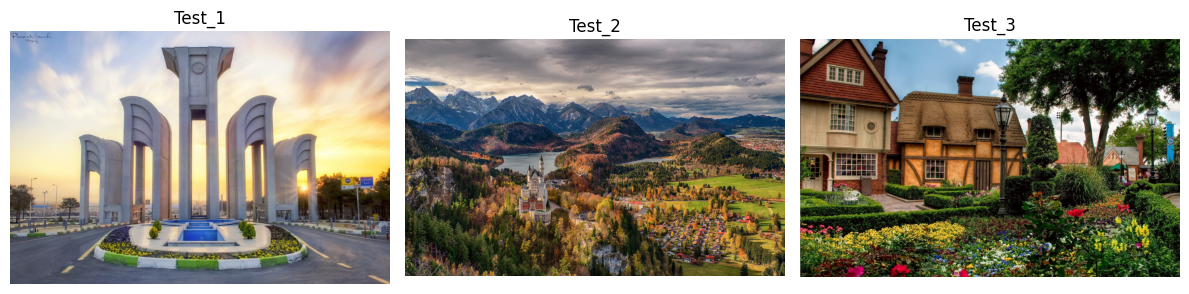

In [11]:
ppm_img1, _, _, _ = read_ppm('data/Q2/Test_1.ppm')
ppm_img2, _, _, _ = read_ppm('data/Q2/Test_2.ppm')
ppm_img3, _, _, _ = read_ppm('data/Q2/Test_3.ppm')


plt.figure(figsize=(12, 4))

titles = ['Test_1', 'Test_2', 'Test_3']
images = [ppm_img1, ppm_img2, ppm_img3]

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# MSE For images

In [5]:
def mean_square_error(image1: np.ndarray, image2: np.ndarray):
    if image1.shape != image2.shape:
        print('Input images don’t have the same shape')
        return -1

    img1_flat = image1.flatten()
    img2_flat = image2.flatten()


    error = img1_flat - img2_flat
    error_square = error ** 2
    error_square_sum = np.sum(error_square)
    mean_error_square_sum = error_square_sum / len(img1_flat)
    return mean_error_square_sum

## Evaluate the MSE

In [18]:
img1 = cv2.imread('data/Q2/Test_2.ppm', cv2.IMREAD_COLOR)
img2 = cv2.imread('data/Q2/Test_2.ppm', cv2.IMREAD_COLOR)

mean_square_error(img1, img2)

0.0

In [19]:
white_image = np.zeros((255, 255)) + 255
black_image = np.zeros((255, 255))

mean_square_error(white_image, black_image)

65025.0

# PSNR

In [37]:
def peak_signal_noise_ratio(image1: np.ndarray, image2: np.ndarray, max_value=255):
    if image1.shape != image2.shape:
        print('Input images don’t have the same shape')
        return -1

    max_value = max_value
    max_value_square = max_value ** 2

    # mean-square-error
    img1_flat = image1.flatten()
    img2_flat = image2.flatten()

    error = img1_flat - img2_flat
    error_square = error ** 2
    error_square_sum = np.sum(error_square)
    mean_error_square_sum = error_square_sum / len(img1_flat)


    return 10 * np.log10(max_value_square / (mean_error_square_sum + 1e-64))

## Evaluate PSNR

In [38]:
img1 = cv2.imread('data/Q2/Test_2.ppm', cv2.IMREAD_COLOR)
img2 = cv2.imread('data/Q2/Test_2.ppm', cv2.IMREAD_COLOR)

peak_signal_noise_ratio(img1, img2)

688.1308036086791

In [39]:
white_image = np.zeros((255, 255)) + 255
black_image = np.zeros((255, 255))

peak_signal_noise_ratio(white_image, black_image)

0.0